# Optimizer control and tolerance

`fit` maximizes the (profiled) likelihood with L-BFGS-B. You rarely need to touch
the optimizer, but a few knobs help when fitting is slow or has not converged.
Pass them through `optimizer_opts`:

```python
model.fit(data, optimizer_opts={"maxiter": 500, "ftol": 1e-9, "gtol": 1e-6})
```

The default is `maxiter=200`. The advice from the README:

> Start with a relatively low value for `maxiter` and increase if better
> performance is needed.

This notebook makes that advice concrete: it shows how the objective, accuracy,
and runtime respond to `maxiter` — and how much wall-clock time each extra bit of
accuracy actually costs — plus how to read the optimizer result.

In [1]:
# !pip install moogp
# !pip install matplotlib

import time
import numpy as np
import matplotlib.pyplot as plt

from moogp.model import MOOGP
from moogp.datasets import generate_borehole_data_nd
from moogp import evaluation

## 1. Convergence vs `maxiter`, and the time it costs

We refit a [borehole emulation problem](https://www.sfu.ca/~ssurjano/borehole.html) (4-D inputs, 6 noisy outputs, 300 training
points) for a range of `maxiter` budgets, tracking the final NLL, the held-out
RMSE, and the wall-clock time. This fit is big enough to take real time, so the
trade-off is visible: extra iterations keep lowering the objective, but the
accuracy you buy per second shrinks quickly.

In [2]:
# Borehole emulation: 4-D inputs, 6 outputs, with a little measurement noise.
# Split the rows into a training set and a held-out test set.
p, n_train = 6, 300
d = generate_borehole_data_nd(n=n_train + 80, p=p, seed=3)
X, Y = np.asarray(d["X_scaled"], float), np.asarray(d["Y"], float)

rng = np.random.default_rng(0)
Y_noisy = Y + rng.normal(0, 0.02 * Y.std(axis=0), size=Y.shape)     # 2% measurement noise
idx = rng.permutation(X.shape[0])
tr, te = idx[:n_train], idx[n_train:]
train = {"X": X[tr], "Y": Y_noisy[tr]}
X_te, F_te = X[te], Y[te]                                           # test against noise-free truth

MOOGP(terms=[None], q=3, learn_sigma_eps=True).fit(train, optimizer_opts={"maxiter": 3})  # warm up timers

budgets = [3, 5, 8, 12, 20, 35, 60, 100, 150, 200]
rows = []
for mi in budgets:
    t0 = time.perf_counter()
    m = MOOGP(terms=[None], q=3, learn_sigma_eps=True)
    m.fit(train, optimizer_opts={"maxiter": mi})
    dt = time.perf_counter() - t0
    rmse = evaluation.rmse(F_te, m.predict(X_te))
    rows.append((mi, m.nll_hat, rmse, m.opt_result.nit, dt))
    print(f"maxiter={mi:4d}  NLL={m.nll_hat:8.3f}  RMSE={rmse:7.3f}  "
          f"nit={m.opt_result.nit:3d}  time={dt:5.2f}s  success={m.opt_result.success}")

maxiter=   3  NLL=  89.445  RMSE= 18.531  nit=  3  time= 0.06s  success=False
maxiter=   5  NLL=  13.492  RMSE=  5.515  nit=  5  time= 0.08s  success=False


maxiter=   8  NLL=  -4.841  RMSE=  4.318  nit=  8  time= 0.12s  success=False
maxiter=  12  NLL= -10.286  RMSE=  3.569  nit= 12  time= 0.16s  success=False


maxiter=  20  NLL= -11.448  RMSE=  2.292  nit= 20  time= 0.25s  success=False


maxiter=  35  NLL= -12.816  RMSE=  1.820  nit= 35  time= 0.46s  success=False


maxiter=  60  NLL= -13.109  RMSE=  1.678  nit= 60  time= 0.80s  success=False


maxiter= 100  NLL= -13.154  RMSE=  1.671  nit=100  time= 1.29s  success=False


maxiter= 150  NLL= -13.175  RMSE=  1.650  nit=150  time= 1.96s  success=False


maxiter= 200  NLL= -13.181  RMSE=  1.644  nit=200  time= 2.63s  success=False


knee: within 5% of best RMSE at maxiter=60 (0.80s); the full budget needs 2.63s for RMSE 1.644


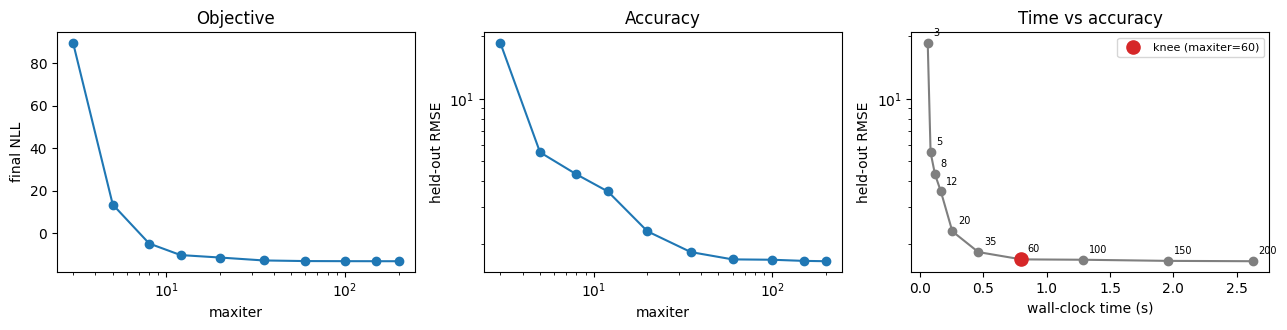

In [3]:
mis, nlls, rmses, nits, times = map(np.array, zip(*rows))

# knee = cheapest budget within 5% of the best RMSE achieved
best = rmses.min()
knee = int(np.argmax(rmses <= 1.05 * best))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(mis, nlls, "o-")
axes[0].set(xscale="log", xlabel="maxiter", ylabel="final NLL", title="Objective")

axes[1].plot(mis, rmses, "o-")
axes[1].set(xscale="log", yscale="log", xlabel="maxiter",
            ylabel="held-out RMSE", title="Accuracy")

# The "money" plot: performance vs the time you paid for it.
ax = axes[2]
ax.plot(times, rmses, "o-", color="tab:gray", zorder=1)
ax.scatter(times[knee], rmses[knee], s=90, color="tab:red", zorder=3,
           label=f"knee (maxiter={mis[knee]})")
for t, r, mi in zip(times, rmses, mis):
    ax.annotate(str(mi), (t, r), textcoords="offset points", xytext=(4, 5), fontsize=7)
ax.set(yscale="log", xlabel="wall-clock time (s)", ylabel="held-out RMSE",
       title="Time vs accuracy")
ax.legend(fontsize=8)
fig.tight_layout()

print(f"knee: within 5% of best RMSE at maxiter={mis[knee]} ({times[knee]:.2f}s); "
      f"the full budget needs {times[-1]:.2f}s for RMSE {best:.3f}")

In the third panel, held-out RMSE against wall-clock time traces
an "L" — accuracy plummets in the first fraction of a second, then flattens. The
knee (red) lands around `maxiter=60`, capturing nearly all the achievable accuracy;
the largest budgets sit on the flat tail, costing several times longer for a
marginal gain. Starting `maxiter` low and raising it until the metrics stop
improving spends your time where it actually buys accuracy.

## 2. Reading the optimizer result

`model.opt_result` is the raw SciPy `OptimizeResult`. Note that
`success=False` often just means L-BFGS-B hit `maxiter` or its tolerance, not
that the fit is unusable — always look at the actual objective/metrics too.

In [4]:
m = MOOGP(terms=[None], q=3, learn_sigma_eps=True)
m.fit(train, optimizer_opts={"maxiter": 5})   # deliberately too few iterations
r = m.opt_result
print("success :", r.success)
print("status  :", r.status)
print("message :", r.message)
print("nit     :", r.nit, "  nfev:", r.nfev)
print("final NLL:", round(m.nll_hat, 4))

success : False
status  : 1
message : STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
nit     : 5   nfev: 7
final NLL: 13.4919


## 3. Tolerances: `ftol` and `gtol`

`ftol` stops when the relative objective change between iterations is small;
`gtol` stops when the projected gradient is small. Loosening them ends the
optimization sooner (fewer iterations); tightening them runs longer in pursuit of
a more precise optimum.

In [5]:
for ftol in [1e-3, 1e-6, 1e-12]:
    m = MOOGP(terms=[None], q=3, learn_sigma_eps=True)
    m.fit(train, optimizer_opts={"maxiter": 500, "ftol": ftol, "gtol": 1e-8})
    print(f"ftol={ftol:.0e}  nit={m.opt_result.nit:3d}  NLL={m.nll_hat:.6f}")

ftol=1e-03  nit= 23  NLL=-11.727846


ftol=1e-06  nit=179  NLL=-13.180092


ftol=1e-12  nit=500  NLL=-13.188964


### Takeaways

  * Tune the optimizer through `optimizer_opts`; the default is `maxiter=200`.
  * Accuracy vs wall-clock time is an **L**: most of the gain comes early, so
    increase `maxiter` only until the NLL / held-out accuracy plateaus, then stop.
  * `success=False` usually means "hit `maxiter`/tolerance" — check the metrics,
    not just the flag.
  * `ftol` / `gtol` trade fit precision against runtime (looser = fewer iterations).